
--- BACKTEST AGGRESSIVO (LONG & SHORT) SU AAPL ---


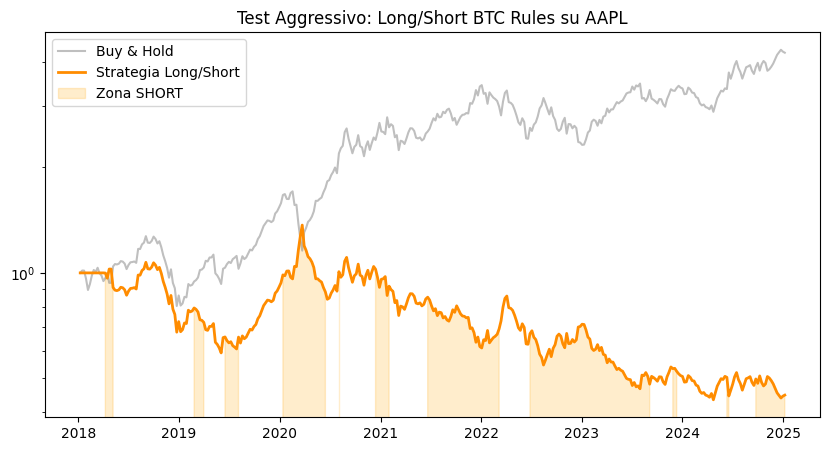

RISULTATI AAPL: Strat: -55.21% | Buy&Hold: 325.13%

--- BACKTEST AGGRESSIVO (LONG & SHORT) SU GOOG ---


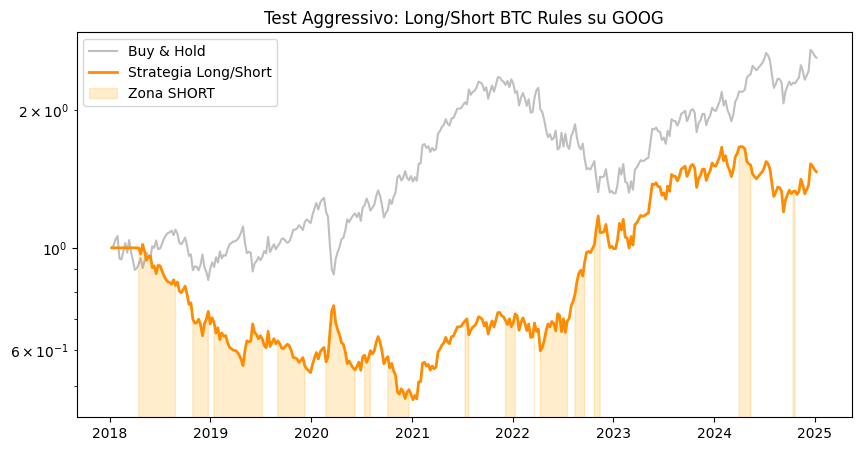

RISULTATI GOOG: Strat: 46.45% | Buy&Hold: 159.49%

--- BACKTEST AGGRESSIVO (LONG & SHORT) SU NFLX ---


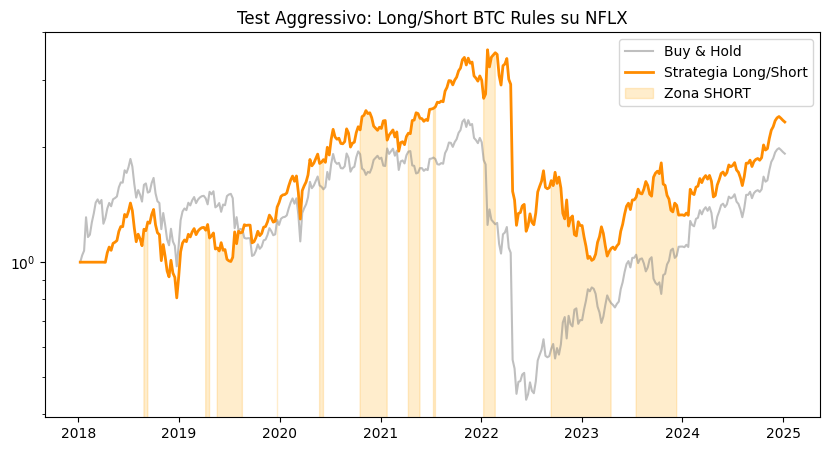

RISULTATI NFLX: Strat: 133.04% | Buy&Hold: 92.51%

--- BACKTEST AGGRESSIVO (LONG & SHORT) SU AMZN ---


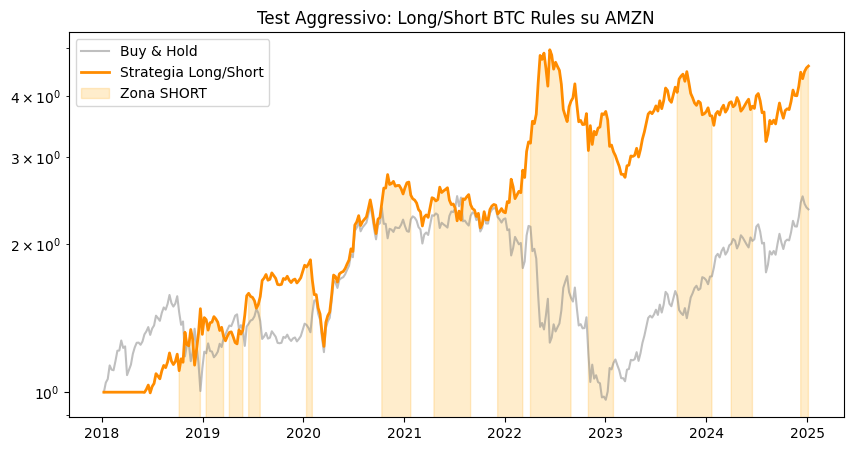

RISULTATI AMZN: Strat: 359.43% | Buy&Hold: 135.13%

--- BACKTEST AGGRESSIVO (LONG & SHORT) SU GC=F ---


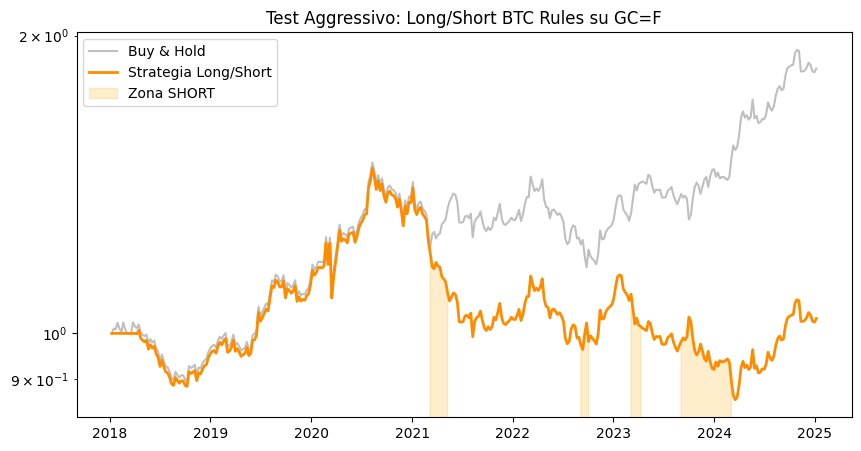

RISULTATI GC=F: Strat: 3.53% | Buy&Hold: 85.21%

--- BACKTEST AGGRESSIVO (LONG & SHORT) SU MRNA ---


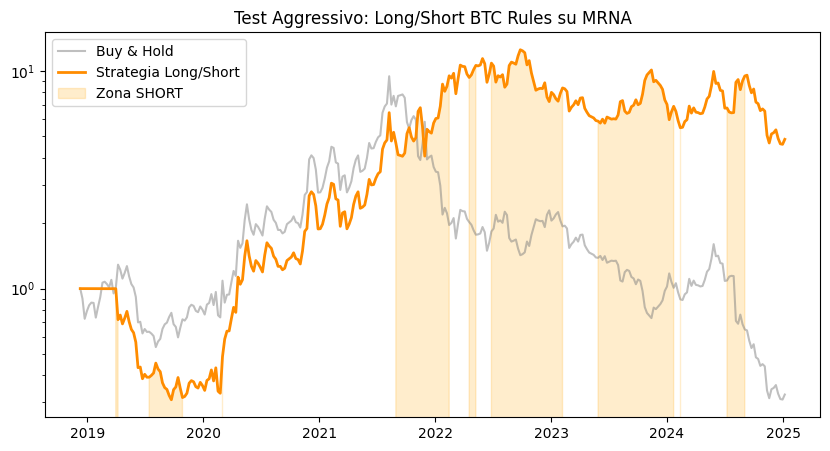

RISULTATI MRNA: Strat: 385.26% | Buy&Hold: -67.40%


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- LISTA ASSET ---
TICKERS = ["AAPL", "GOOG", "NFLX", "AMZN", "GC=F", "MRNA"]
START_DATE = "2018-01-01"
END_DATE = "2025-01-01"
COSTO_TRANSAZIONE = 0.001 

for ticker in TICKERS:
    print(f"\n--- BACKTEST AGGRESSIVO (LONG & SHORT) SU {ticker} ---")
    
    data = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    df = data.resample('W-MON').apply({'Close': 'last', 'Volume': 'sum'}).dropna()

    df['log_ret'] = np.log(df['Close'] / df['Close'].shift(1))
    df['skew'] = df['log_ret'].rolling(window=12).skew().shift(1)
    df['vol_force'] = df['Volume'].pct_change().rolling(window=4).mean().shift(1)

    # --- STATE MACHINE CON SHORT ---
    positions = []
    current_pos = 0 

    for i in range(len(df)):
        skew = df['skew'].iloc[i]
        vol = df['vol_force'].iloc[i]
        
        if pd.isna(skew) or pd.isna(vol):
            positions.append(0); continue
            
        # 1. SEGNALI LONG
        is_long = (skew > 0.2 and vol > 0.05) or (skew > 0.6) or (skew < -0.8 and vol < -0.1)
        
        # 2. SEGNALE SHORT (LA TRAPPOLA)
        is_short = (-0.5 < skew < -0.1 and vol < 0.05)
        
        if is_long:
            current_pos = 1 
        elif is_short:
            current_pos = -1 # <--- QUI ABBIAMO AGGIUNTO IL SELL (SHORT)
        else:
            # Opzionale: se non è né carne né pesce, andiamo a 0 o manteniamo?
            # Per ora manteniamo lo stato per non fare troppi trade
            pass 
            
        positions.append(current_pos)

    df['position'] = positions

    # PERFORMANCE
    df['strat_ret'] = df['position'].shift(1) * df['log_ret']
    trades = df['position'].diff().abs()
    df['strat_ret_net'] = df['strat_ret'] - (trades * COSTO_TRANSAZIONE)

    df['equity_strat'] = (1 + df['strat_ret_net'].fillna(0)).cumprod()
    df['equity_bh'] = (1 + df['log_ret'].fillna(0)).cumprod()

    # VISUALIZZAZIONE
    plt.figure(figsize=(10, 5))
    plt.plot(df['equity_bh'], label='Buy & Hold', color='grey', alpha=0.5)
    plt.plot(df['equity_strat'], label='Strategia Long/Short', color='darkorange', linewidth=2)
    
    # Evidenziamo le zone di SHORT (Arancione chiaro)
    plt.fill_between(df.index, df['equity_strat'], 0, where=(df['position']==-1), color='orange', alpha=0.2, label='Zona SHORT')

    plt.title(f"Test Aggressivo: Long/Short BTC Rules su {ticker}")
    plt.yscale('log')
    plt.legend()
    plt.show()

    tot_strat = (df['equity_strat'].iloc[-1] - 1) * 100
    print(f"RISULTATI {ticker}: Strat: {tot_strat:.2f}% | Buy&Hold: {(df['equity_bh'].iloc[-1]-1)*100:.2f}%")